In [1]:
#1、读取数据
import pandas as pd
import numpy as np

data = pd.read_csv("Tuesday-WorkingHours.pcap_ISCX.csv")
data.columns = data.columns.str.strip()#去除标签前后的空格

In [2]:
#2、清洗数据
data.isnull().sum()

Destination Port               0
Flow Duration                  0
Total Fwd Packets              0
Total Backward Packets         0
Total Length of Fwd Packets    0
                              ..
Idle Mean                      0
Idle Std                       0
Idle Max                       0
Idle Min                       0
Label                          0
Length: 79, dtype: int64

In [3]:
numeric_df = data.select_dtypes(include=[np.number])
np.isinf(numeric_df).sum()

Destination Port               0
Flow Duration                  0
Total Fwd Packets              0
Total Backward Packets         0
Total Length of Fwd Packets    0
                              ..
Active Min                     0
Idle Mean                      0
Idle Std                       0
Idle Max                       0
Idle Min                       0
Length: 78, dtype: int64

In [4]:
data.replace([np.inf, -np.inf], np.nan, inplace=True)

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,88,640,7,4,440,358,220,0,62.857143,107.349008,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,88,900,9,4,600,2944,300,0,66.666667,132.287566,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,88,1205,7,4,2776,2830,1388,0,396.571429,677.274651,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,88,511,7,4,452,370,226,0,64.571429,110.276708,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,88,773,9,4,612,2944,306,0,68.000000,134.933317,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
445904,53,155,2,2,88,120,44,44,44.000000,0.000000,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
445905,59317,110,1,1,0,0,0,0,0.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
445906,53,166,2,2,88,188,44,44,44.000000,0.000000,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
445907,54726,81,1,1,0,0,0,0,0.000000,0.000000,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


少量缺失,缺失率 < 1%（你大概率是这个情况）→ 直接删

中等缺失,缺失率 1%~10%→ 中位数填充

大量缺失，缺失率 > 30%->  考虑删列

别优先用均值填充网络流量数据

In [5]:
#计算缺失率
print(f"{(data.isnull().sum().sum()/data.shape[0])*100}%")

0.11840981007335577%


In [6]:
data.dropna(inplace=True)

In [7]:
#3、标签映射，BENIGN为0，其余均为1
data['Label']=(data['Label']!='BENIGN').astype(int)

# 特征选择
1. 手工删除明显不该参与训练的字段
2. 方差筛选，删掉几乎不变化的列
3. 相关系数筛选，看每个特征和 Label 的相关性，选相关性高的特征；或者使用SelectKBest

In [8]:
#4、特征选择
#4.1 手工删除明显不该参与训练的字段
#如果包含以下字段可以直接删除
drop_cols = [
    'Flow ID', 'Source IP', 'Source Port',
    'Destination IP', 'Timestamp'
]#Destination Port不能默认删除
data.drop(drop_cols, axis=1, inplace=True,errors='ignore')#axis=1指定删除的对象是列

In [9]:
#4.2 方差筛选，删掉几乎不变化的列
#注意VarianceThreshold只能处理数值特征，若数据中有离散字符串类别，请先做编码（如 LabelEncoder 或 OneHotEncoder）。
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0)
selector.fit(data)
data.columns[~selector.get_support()].tolist()#查看删除的列,~表示数组按位取反
data = data.loc[:, selector.get_support()]

In [10]:
#4.3 ①相关系数筛选，看每个特征和 Label 的相关性，选相关性高的特征
#着重单变量线性相关
# corr = data.corr(numeric_only=True)['Label'].abs()
# temp = corr.sort_values(ascending=False).head(16)
# features = temp.index.tolist()#remove是原地修改（in-place），它会直接改列表本身，但不返回新列表
# features.remove('Label')
# y= data['Label']
# data=data[features]

使用SelectKBest的原理：利用单变量统计检验，独立评估每个特征与目标变量的相关性，完全不考虑特征间的组合效应。优点是计算快速、易解释，适合在高维数据中快速去除无关特征。

In [11]:
#②使用SelectKBest
#着重类别分离能力
from sklearn.feature_selection import SelectKBest, f_classif
#指定评分函数为分类任务中的 ANOVA F 检验，k=10：保留得分最高的 10 个特征，如果 k 是一个浮点数（如 0.3），则保留 30% 的特征。
selector = SelectKBest(score_func=f_classif, k=15)
x = data.drop('Label', axis=1)
y= data['Label']
selector.fit(x, y)
features = x.columns[selector.get_support()].tolist()
data=data[features]

In [12]:
#4.4 划分数据集
from sklearn.model_selection import train_test_split

#test_size=0.2表示20%测试集和80% 训练集，stratify=y表示分层抽样
X_train, X_test, y_train, y_test = train_test_split(
    data,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print(X_train.shape)
print(X_test.shape)
print(y_train.value_counts())
print(y_test.value_counts())

(356516, 15)
(89129, 15)
Label
0    345450
1     11066
Name: count, dtype: int64
Label
0    86363
1     2766
Name: count, dtype: int64


In [13]:
# 5、特征缩放
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# 用训练集拟合并转换
X_train_scaled = scaler.fit_transform(X_train)

# 测试集只转换
X_test_scaled = scaler.transform(X_test)

In [14]:
#6、模型训练
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(class_weight='balanced',max_iter=1000)
model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [15]:
#7、评估
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred)
print("准确率:", acc)

准确率: 0.9259163684098329


In [16]:
#8、分类报告
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.92      0.96     86363
           1       0.30      1.00      0.46      2766

    accuracy                           0.93     89129
   macro avg       0.65      0.96      0.71     89129
weighted avg       0.98      0.93      0.94     89129



[[79763  6600]
 [    3  2763]]


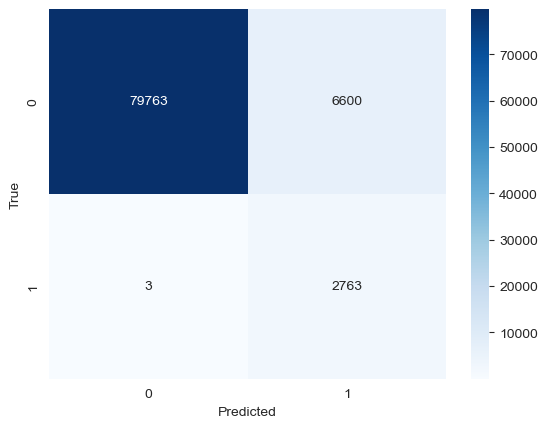

In [17]:
#9、混淆矩阵
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
print(cm)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [18]:
#10、模型拯救
#①阶级权重惩罚 (Class Weight)
#model = LogisticRegression(class_weight='balanced')